In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
df = pd.read_csv('diabetic_data.csv')
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [69]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [7]:
df.shape

(101766, 50)

In [10]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

Since max_glu_serum and A1Cresult have high number of null values, we can drop them

In [70]:
df.drop(columns=["max_glu_serum" , "A1Cresult"], inplace=True)

In [71]:
df.isnull().sum()

encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
weight                      0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
payer_code                  0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose  

Since there is no value given in weight, we can drop it. 

Also encounter_id, payer_code, medical_specialty and patient_nbr column do not provide any significant information for this model, we can drop them too.

In [72]:
df.drop(columns=["weight" , "payer_code", "encounter_id","payer_code", "medical_specialty",	"patient_nbr", 'diag_1','diag_2', 'diag_3','examide', 'citoglipton'], inplace=True)

In [73]:
df.head(5)

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [46]:
df.duplicated().sum()

np.int64(6)

In [74]:
df.drop_duplicates(inplace=True)

In [75]:
df.describe()

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101760.000000,101760.000000,101760.000000,101760.000000,101760.000000,101760.000000,101760.000000,101760.000000,101760.000000,101760.000000,101760.000000
mean,2.024027,3.715753,5.754481,4.396108,43.096747,1.339741,16.022199,0.369379,0.197848,0.635603,7.422651
std,1.445425,5.280282,4.064138,2.985148,19.673891,1.705774,8.127592,1.267299,0.930498,1.262891,1.933518
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101760 entries, 0 to 101765
Data columns (total 38 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      101760 non-null  object
 1   gender                    101760 non-null  object
 2   age                       101760 non-null  object
 3   admission_type_id         101760 non-null  int64 
 4   discharge_disposition_id  101760 non-null  int64 
 5   admission_source_id       101760 non-null  int64 
 6   time_in_hospital          101760 non-null  int64 
 7   num_lab_procedures        101760 non-null  int64 
 8   num_procedures            101760 non-null  int64 
 9   num_medications           101760 non-null  int64 
 10  number_outpatient         101760 non-null  int64 
 11  number_emergency          101760 non-null  int64 
 12  number_inpatient          101760 non-null  int64 
 13  number_diagnoses          101760 non-null  int64 
 14  metformin

Mapping all the age with their midpoints and converting them into integer

In [77]:
df['age'] = df['age'].replace({'[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35, '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75, '[80-90)': 85, '[90-100)': 95})
df['age'] = df['age'].astype('int')
df.head()

C:\Users\MSII\AppData\Local\Temp\ipykernel_18920\1616361854.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['age'] = df['age'].replace({'[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35, '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75, '[80-90)': 85, '[90-100)': 95})


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,5,6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,15,1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,25,1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,35,1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,45,1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [78]:
df[df.select_dtypes(include= ['object']).columns] = df.select_dtypes(include='object').astype('category')

Applying One Hot Encoding on the features

In [79]:
df=pd.get_dummies(df,columns=[ 'gender','race'])

In [98]:
cat_cols = df.select_dtypes(include='category').columns

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [ ]:
df=pd.get_dummies(df,columns=[ 'change', 'diabetesMed'])


Converting all boolean values to numerical value

In [101]:
df[df.select_dtypes(include='bool').columns] = df.select_dtypes(include='bool').astype(int)

In [102]:
df.head()

,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,...,insulin_Up,glyburide-metformin_No,glyburide-metformin_Steady,glyburide-metformin_Up,glipizide-metformin_Steady,glimepiride-pioglitazone_Steady,metformin-rosiglitazone_Steady,metformin-pioglitazone_Steady,readmitted_>30,readmitted_NO
0,5,6,25,1,1,41,0,1,0,0,...,0,1,0,0,0,0,0,0,0,1
1,15,1,1,7,3,59,0,18,0,0,...,1,1,0,0,0,0,0,0,1,0
2,25,1,1,7,2,11,5,13,2,0,...,0,1,0,0,0,0,0,0,0,1
3,35,1,1,7,2,44,1,16,0,0,...,1,1,0,0,0,0,0,0,0,1
4,45,1,1,7,1,51,0,8,0,0,...,0,1,0,0,0,0,0,0,0,1


In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101760 entries, 0 to 101765
Data columns (total 75 columns):
 #   Column                           Non-Null Count   Dtype
---  ------                           --------------   -----
 0   age                              101760 non-null  int64
 1   admission_type_id                101760 non-null  int64
 2   discharge_disposition_id         101760 non-null  int64
 3   admission_source_id              101760 non-null  int64
 4   time_in_hospital                 101760 non-null  int64
 5   num_lab_procedures               101760 non-null  int64
 6   num_procedures                   101760 non-null  int64
 7   num_medications                  101760 non-null  int64
 8   number_outpatient                101760 non-null  int64
 9   number_emergency                 101760 non-null  int64
 10  number_inpatient                 101760 non-null  int64
 11  number_diagnoses                 101760 non-null  int64
 12  gender_Female                    10

In [104]:
df_num = df.select_dtypes(include=['int64', 'float64'])
df_num.corr()

,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,...,insulin_Up,glyburide-metformin_No,glyburide-metformin_Steady,glyburide-metformin_Up,glipizide-metformin_Steady,glimepiride-pioglitazone_Steady,metformin-rosiglitazone_Steady,metformin-pioglitazone_Steady,readmitted_>30,readmitted_NO
age,1.000000,-0.007224,0.114293,0.044685,0.107491,0.020742,-0.030147,0.041794,0.023706,-0.087314,...,-0.050919,0.001512,-0.001575,0.000852,0.002041,-0.000190,0.002512,-0.000190,0.020120,-0.030368
admission_type_id,-0.007224,1.000000,0.083484,0.106681,-0.012507,-0.143740,0.129857,0.079527,0.026507,-0.019119,...,0.019401,0.003273,-0.003278,0.002153,-0.004399,-0.002221,-0.000074,0.002117,0.002538,0.004936
discharge_disposition_id,0.114293,0.083484,1.000000,0.018185,0.162738,0.023407,0.015926,0.108741,-0.008721,-0.024476,...,0.001199,0.004492,-0.003766,-0.004560,0.000444,-0.001612,-0.000181,-0.000425,-0.048918,0.014852
admission_source_id,0.044685,0.106681,0.018185,1.000000,-0.006976,0.048881,-0.135370,-0.054544,0.027242,0.059891,...,0.006548,0.024198,-0.023894,-0.003282,-0.000387,0.000961,-0.001914,-0.003667,0.037976,-0.039995
time_in_hospital,0.107491,-0.012507,0.162738,-0.006976,1.000000,0.318428,0.191494,0.466121,-0.008928,-0.009690,...,0.100091,0.002168,-0.002127,-0.004518,-0.000626,-0.002516,-0.000588,0.001684,0.024445,-0.051292
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
glimepiride-pioglitazone_Steady,-0.000190,-0.002221,-0.001612,0.000961,-0.002516,-0.000812,-0.002462,-0.003480,-0.000914,-0.000667,...,-0.001109,0.000262,-0.000259,-0.000028,-0.000035,1.000000,-0.000014,-0.000010,0.004279,-0.003390
metformin-rosiglitazone_Steady,0.002512,-0.000074,-0.000181,-0.001914,-0.000588,0.001218,0.004315,0.007897,-0.001292,-0.000943,...,-0.001568,0.000371,-0.000367,-0.000039,-0.000050,-0.000014,1.000000,-0.000014,-0.003248,0.004099
metformin-pioglitazone_Steady,-0.000190,0.002117,-0.000425,-0.003667,0.001684,-0.003202,-0.000624,0.001534,-0.000914,-0.000667,...,-0.001109,0.000262,-0.000259,-0.000028,-0.000035,-0.000010,-0.000014,1.000000,-0.002297,0.002898
readmitted_>30,0.020120,0.002538,-0.048918,0.037976,0.024445,0.027610,-0.038759,0.023531,0.073408,0.067585,...,0.026850,-0.002833,0.003837,-0.004171,0.004485,0.004279,-0.003248,-0.002297,1.000000,-0.792380


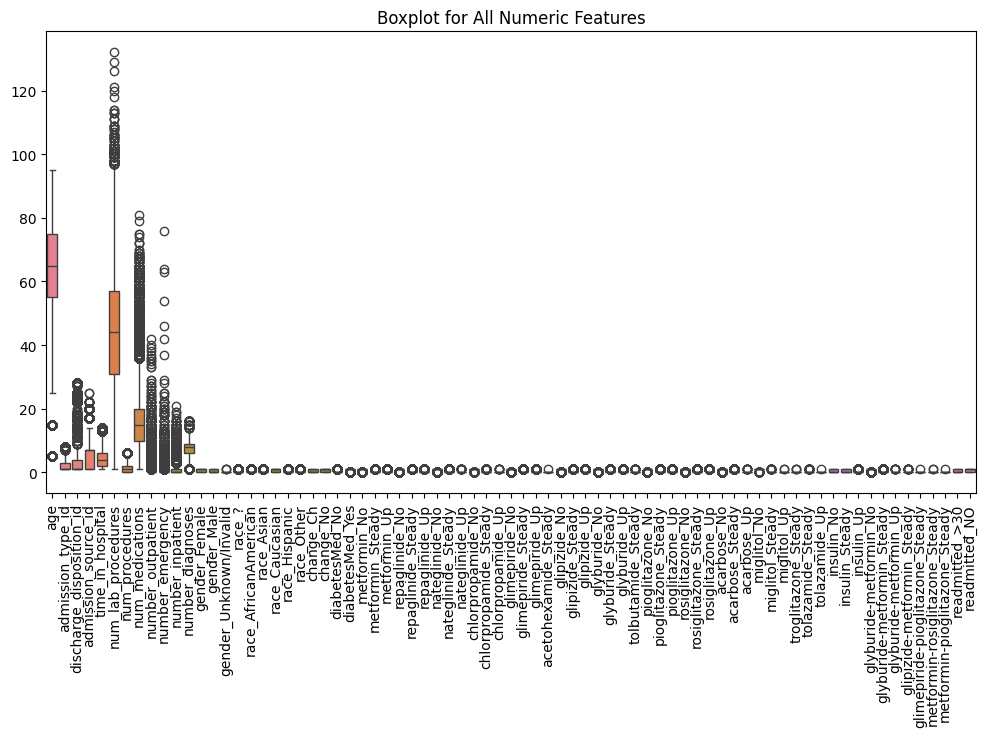

In [107]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include=['int64', 'float64']))
plt.xticks(rotation=90)
plt.title("Boxplot for All Numeric Features")
plt.show()

Splitting of dataset into target and dataset except target

In [109]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

Splitting the data

In [110]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2,random_state=42) 

Normalization

In [112]:
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()

x_train_scale = scale.fit_transform(X_train)
x_test_scale = scale.transform(X_test)

In [ ]:
from sklearn.model_selection import LinearRegression

model = LinearRegression()
